In [30]:
import tensorflow as tf
import numpy as np
from lime.lime_image import LimeImageExplainer
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from tensorflow.keras import layers

In [31]:
dataset=tf.keras.preprocessing.image_dataset_from_directory("Oxford 17 Flowers")

Found 1360 files belonging to 16 classes.


(32, 256, 256, 3)


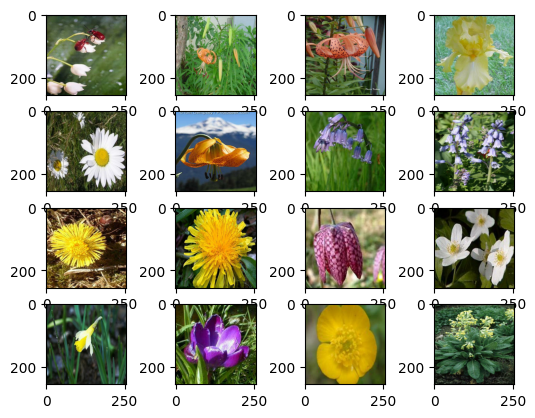

In [32]:
for i,l in dataset.take(1):
    print(i.shape)
    for j in range(16):
        plt.subplot(4,4,j+1)
        plt.imshow(i[j].numpy().astype('uint8'))

In [33]:
train_ds_size=len(dataset)*0.8
train_ds=dataset.take(34)

In [34]:
test_ds=dataset.skip(34)

In [35]:
model=tf.keras.models.Sequential([
    layers.Flatten(input_shape=(256, 256, 3)),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(dataset.class_names),activation='softmax')
])

C:\Users\ADMIN\tf_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 4: Train the model
model.fit(train_ds, epochs=10)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 560ms/step - accuracy: 0.0838 - loss: 21419.3945
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 510ms/step - accuracy: 0.2196 - loss: 3465.7747
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 511ms/step - accuracy: 0.2947 - loss: 1340.4308
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 511ms/step - accuracy: 0.3351 - loss: 953.8604 
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 525ms/step - accuracy: 0.4087 - loss: 546.5884
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 517ms/step - accuracy: 0.4887 - loss: 460.2966
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 535ms/step - accuracy: 0.5057 - loss: 428.8753
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 553ms/step - accuracy: 0.5315 - loss: 327.0547
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 520ms/step - accuracy: 0.6282 - loss: 239.4352
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 511ms/step - accuracy: 0.4717 - loss: 549.3774


In [43]:
for images, labels in dataset.take(1):
    sample_image = images[0].numpy()  # Get first image
    sample_label = labels[0].numpy()  # Get corresponding label
    break

In [44]:
def predict_fn(images):
    # No normalization; images are expected in [0, 255]
    images = np.array(images)  # Convert to NumPy array
    return model.predict(images, verbose=0)
explainer = LimeImageExplainer()
explanation = explainer.explain_instance(
    sample_image,
    predict_fn,
    top_labels=5,
    num_samples=2000
)

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:30<00:00, 22.15it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


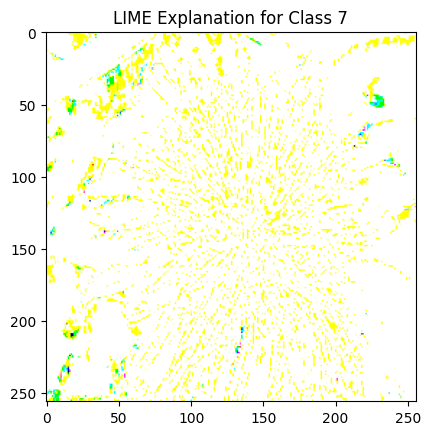

In [51]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=5,
    hide_rest=False
)
plt.imshow(mark_boundaries(sample_image, mask))
plt.title(f'LIME Explanation for Class {sample_label}')
plt.show()

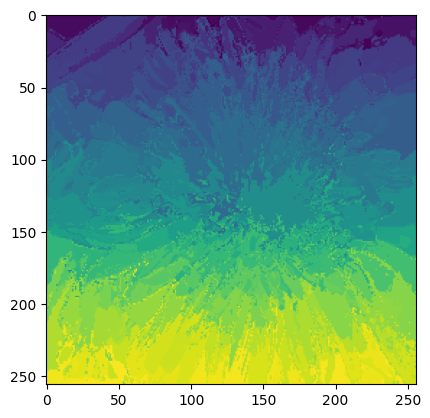

In [54]:
plt.imshow(explanation.segments)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


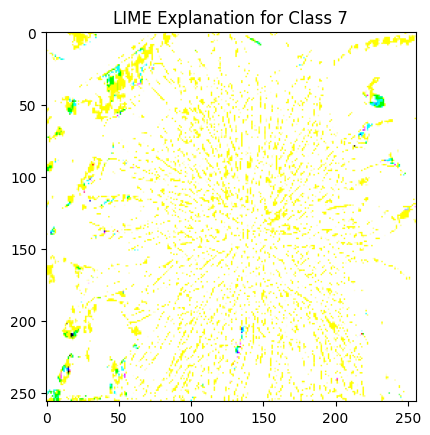

In [55]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)
plt.imshow(mark_boundaries(sample_image, mask))
plt.title(f'LIME Explanation for Class {sample_label}')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


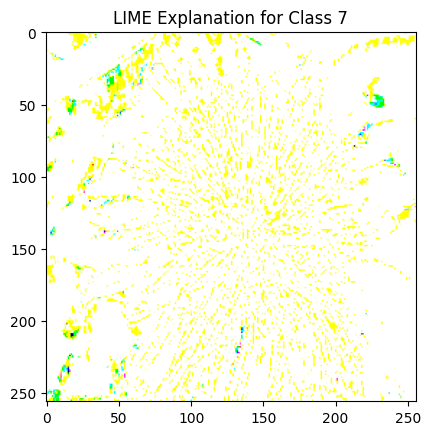

In [56]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=5,
    hide_rest=True
)
plt.imshow(mark_boundaries(sample_image, mask))
plt.title(f'LIME Explanation for Class {sample_label}')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


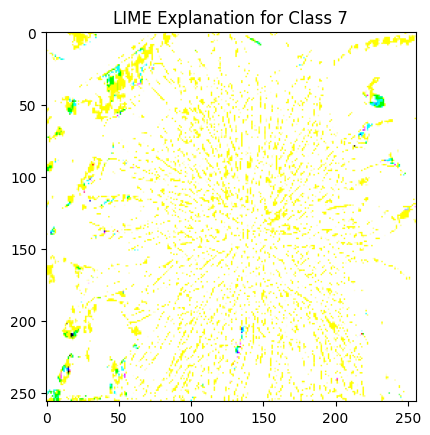

In [58]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    min_weight=0.0001,
    positive_only=False,
    num_features=5,
    hide_rest=False
)
plt.imshow(mark_boundaries(sample_image, mask))
plt.title(f'LIME Explanation for Class {sample_label}')
plt.show()